In [1]:
!apt-get update -qq
!apt-get install -y -qq python3.12-venv

# ============================================================
# Persistent OpenVLA environment on Google Drive
# Installs only when required versions are missing/different
# ============================================================

import os
import sys
import subprocess
import shutil
import importlib.metadata as metadata

from google.colab import drive

# ------------------------------------------------------------
# 1. Mount Google Drive
# and Persistent Hugging Face cache
# ------------------------------------------------------------

drive.mount("/content/drive")


HF_CACHE = "/content/drive/MyDrive/huggingface_cache"

os.makedirs(HF_CACHE, exist_ok=True)

os.environ["HUGGINGFACE_HUB_CACHE"] = HF_CACHE

print("Hugging Face cache:", HF_CACHE)

ENV_PATH = "/content/drive/MyDrive/colab_env_openvla"
VENV_PYTHON = os.path.join(ENV_PATH, "bin", "python")

'''
if os.path.exists(ENV_PATH):
    print("Removing old/non-venv directory:")
    print(ENV_PATH)
    shutil.rmtree(ENV_PATH)
'''

print("Creating fresh persistent venv...")

# ------------------------------------------------------------
# 2. Versions we require
# ------------------------------------------------------------

REQUIRED = {
    "transformers": "4.40.1",
    "tokenizers": "0.19.1",
    "accelerate": "0.26.0",
    "timm": "0.9.10",
    "peft": "0.11.1",
    "sentencepiece": "0.1.99",
    "draccus": "0.8.0",
}

# ------------------------------------------------------------
# 3. Create persistent venv if necessary
# ------------------------------------------------------------

if not os.path.exists(VENV_PYTHON):

    print("================================================")
    print("Creating persistent OpenVLA environment")
    print("================================================")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "venv",
            "--system-site-packages",
            ENV_PATH,
        ],
        check=True,
    )

    print("✅ Virtual environment created")
else:
    print("✅ Persistent environment already exists")


# ------------------------------------------------------------
# 4. Check installed versions INSIDE the venv
# ------------------------------------------------------------

def get_installed_version(package):
    """
    Ask the persistent venv's Python which version is installed.
    """
    result = subprocess.run(
        [
            VENV_PYTHON,
            "-c",
            (
                "import importlib.metadata as m; "
                f"print(m.version('{package}'))"
            ),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        return None

    return result.stdout.strip()


print("\n================================================")
print("Checking OpenVLA environment")
print("================================================")

needs_install = []

for package, required_version in REQUIRED.items():

    installed = get_installed_version(package)

    if installed is None:
        print(f"❌ {package}: NOT INSTALLED")
        needs_install.append(package)

    elif required_version is None:
        print(f"✅ {package}: {installed}")

    elif installed != required_version:
        print(
            f"⚠️ {package}: {installed} "
            f"(required {required_version})"
        )
        needs_install.append(package)

    else:
        print(f"✅ {package}: {installed}")


# ------------------------------------------------------------
# 5. Install ONLY if something is missing/wrong
# ------------------------------------------------------------

if needs_install:

    print("\n================================================")
    print("Installing/updating OpenVLA dependencies")
    print("================================================")

    packages = [
        "transformers==4.40.1",
        "tokenizers==0.19.1",
        "accelerate==0.26.0",
        "timm==0.9.10",
        "peft==0.11.1",
        "sentencepiece==0.1.99",
        "draccus==0.8.0",
    ]

    subprocess.run(
        [
            VENV_PYTHON,
            "-m",
            "pip",
            "install",
            "-q",
            *packages,
        ],
        check=True,
    )

    print("✅ Installation/update complete")

else:

    print("\n================================================")
    print("🎉 OpenVLA environment already satisfies all")
    print("   required versions.")
    print("   SKIPPING pip installation.")
    print("================================================")


# ------------------------------------------------------------
# 6. Make the venv packages available to THIS notebook
# ------------------------------------------------------------

# We are using Colab's Python kernel, so add the venv's
# site-packages to sys.path.

PYTHON_VERSION = f"{sys.version_info.major}.{sys.version_info.minor}"

VENV_SITE = os.path.join(
    ENV_PATH,
    "lib",
    f"python{PYTHON_VERSION}",
    "site-packages",
)

if os.path.exists(VENV_SITE):

    if VENV_SITE not in sys.path:
        sys.path.insert(0, VENV_SITE)

    print("\nVenv site-packages:")
    print(VENV_SITE)

else:

    print("\n⚠️ WARNING:")
    print("Could not find:")
    print(VENV_SITE)


# ------------------------------------------------------------
# 7. Final verification
# ------------------------------------------------------------

print("\n================================================")
print("FINAL ENVIRONMENT CHECK")
print("================================================")

print("Notebook Python:")
print(sys.version)

print("\nNotebook executable:")
print(sys.executable)


#import transformers
#import tokenizers
#import accelerate
#import timm
#import peft

#print("\nTransformers :", transformers.__version__)
#print("Tokenizers   :", tokenizers.__version__)
#print("Accelerate   :", accelerate.__version__)
#print("Timm         :", timm.__version__)
##print("PEFT         :", peft.__version__)

#print("\nTransformers loaded from:")
#print(transformers.__file__)

print("\n✅ Persistent OpenVLA environment ready. Installing mujoco and mediapy")

!pip install -q mujoco==3.8.0 mediapy

print("mediapy and mujoco installed")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package python3.12-venv.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../python3.12-venv_3.12.13-1+jammy1_amd64.deb ...
Unpacking python3.12-venv (3.12.13-1+jammy1) ...
Setting up python3.12-venv (3.12.13-1+jammy1) ...
Mounted at /content/drive
Hugging Face cache: /content/drive/MyDrive/huggingface_cache
Creating fresh persistent venv...
✅ Persistent environment already exists

Checking OpenVLA environment
✅ transformers: 4.40.1
✅ tokenizers: 0.19.1
✅ accelerate: 0.26.0
✅ timm: 0.9.10
✅ peft: 0.11.1
✅ sentencepiece: 0.1.99
✅ draccus: 0.8.0

🎉 OpenVLA environment already satisfies all
   required versions.
   SKIPPING pip installation.

Venv site-packages:
/content/drive/MyDrive/colab_env_openvla/lib/python3.12/site-packa

MuJoCo: 3.8.0
MUJOCO_GL: egl
SciPy      : 1.16.3 /usr/local/lib/python3.12/dist-packages/scipy/__init__.py
Mediapy    : /content/drive/MyDrive/colab_env_openvla/lib/python3.12/site-packages/mediapy/__init__.py
PyTorch Version: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
Transformers: 4.40.1
AutoModelForVision2Seq OK
AutoProcessor OK

--- Environment Health Check ---
Active Python:     3.12.13
Active Python Executable: /usr/bin/python3
opened mujoco model

===== Sites =====
0 pinch
Rendered  --- panda is totally fine

===== CAMERAS =====
0 vla_camera pos = [-0.4972514 -0.6661122  1.0092612] quat = [ 0.81949115  0.42660009 -0.17670354 -0.33944435] mode = 0

vla_camera ID: 0
vla_camera pos: [-0.4972514 -0.6661122  1.0092612]
vla_camera quat: [ 0.81949115  0.42660009 -0.17670354 -0.33944435]
vla_camera mode: 0
CUDA available: True


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device: cuda:0
Model dtype: torch.bfloat16
{'': device(type='cuda', index=0)}
✅ OpenVLA-7B loaded successfully!
dict_keys(['smoothed_spatial_action', 'processor', 'vla'])
Cube position: [0.5 0.  0.1]
Hand position: [ 3.07019570e-01 -2.63775365e-33  5.90269558e-01]
🚀 Starting MuJoCo OpenVLA Control Loop...
===== BRIDGE_ORIG ACTION STATS =====
q01: [-0.02872725307941437, -0.04170349963009357, -0.026093858778476715, -0.08092105075716972, -0.09288699507713317, -0.20718276381492615, 0.0]
q99: [0.028309678435325586, 0.040855254605412394, 0.040161586627364146, 0.08192047759890528, 0.07792850524187081, 0.20382574498653397, 1.0]
mask: [True, True, True, True, True, True, False]


""

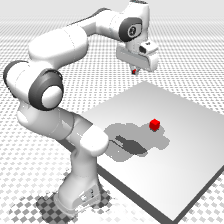

CUBE DIRECTION WORLD: [ 4.43250611e-01  1.03715895e-32 -8.96397733e-01]
VLA XYZ: [-0.00669534 -0.0013954  -0.01141373]
VLA DIRECTION: [-0.50318441 -0.10487062 -0.85779229]
DOT PRODUCT: 0.5458862665992841
CAM cube direction: [ 0.313 -0.555 -0.771]
VLA direction:      [-0.503 -0.105 -0.858]
dot VLA, cube:      0.561709686592377
dot -VLA, cube:     -0.561709686592377
dot flip X: 0.8771313521966939
dot flip Y: 0.44540553474689293
dot flip Z: -0.7608272003512098
Iteration 0 - Raw Action: [-0.00669534 -0.0013954  -0.01141373 -0.0090792   0.01529616 -0.02585548
  0.99607843]
VLA: [-0.00669534 -0.0013954  -0.01141373]
===== EEF FRAME =====
EEF R:
 [[ 1.  0.  0.]
 [ 0. -1. -0.]
 [ 0.  0. -1.]]
EEF local +X in world: [1. 0. 0.]
EEF local +Y in world: [ 0. -1.  0.]
EEF local +Z in world: [ 0. -0. -1.]
delta xyz world: [-0.0067  -0.0014  -0.01141]
CURRENT: [ 0.30702 -0.       0.49027]
TARGET : [ 0.30032 -0.0014   0.47886]
DESIRED MOTION: [-0.0067  -0.0014  -0.01141]
Actual EE motion: [-0.00385139 

""

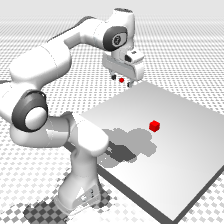

CUBE DIRECTION WORLD: [ 0.5662878  -0.02736352 -0.82375322]
VLA XYZ: [-0.00669534 -0.00074788  0.01067142]
VLA DIRECTION: [-0.53053132 -0.05926136  0.84559128]
DOT PRODUCT: -0.9953703510497247
CAM cube direction: [ 0.42  -0.456 -0.785]
VLA direction:      [-0.531 -0.059  0.846]
dot VLA, cube:      -0.8591578971319453
dot -VLA, cube:     0.8591578971319453
dot flip X: -0.41375045184929726
dot flip Y: -0.9132282424110704
dot flip Z: 0.4678207971284223
Iteration 10 - Raw Action: [-6.69534032e-03 -7.47882333e-04  1.06714178e-02 -5.24763464e-03
 -3.29341038e-02 -3.87498651e-02  9.96078431e-01]
VLA: [-0.00669534 -0.00074788  0.01067142]
===== EEF FRAME =====
EEF R:
 [[ 1.     0.003 -0.008]
 [ 0.002 -1.    -0.001]
 [-0.008  0.001 -1.   ]]
EEF local +X in world: [ 1.     0.002 -0.008]
EEF local +Y in world: [ 0.003 -1.     0.001]
EEF local +Z in world: [-0.008 -0.001 -1.   ]
delta xyz world: [-0.0067  -0.00075  0.01067]
CURRENT: [0.23821 0.01265 0.47071]
TARGET : [0.23151 0.0119  0.48138]
DESI

This browser does not support the video tag.


Gooooooooooooooooood!!!!!


In [9]:
import os
# Force GPU-accelerated offscreen rendering
os.environ["MUJOCO_GL"] = "egl"

import mujoco
print("MuJoCo:", mujoco.__version__)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))

import numpy as np
import PIL.Image

import scipy
print("SciPy      :", scipy.__version__, scipy.__file__)

from scipy.spatial.transform import Rotation as R
import time

import mediapy as media
print("Mediapy    :", media.__file__)

import torch
print("PyTorch Version:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

import transformers
print("Transformers:", transformers.__version__)

from transformers import AutoModelForVision2Seq
print("AutoModelForVision2Seq OK")

from transformers import AutoProcessor
print("AutoProcessor OK")

#from transformers import AutoModelForVision2Seq, AutoProcessor

import sys
print("\n--- Environment Health Check ---")
print(f"Active Python:     {sys.version.split()[0]}")
print(f"Active Python Executable: {sys.executable}")

# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
TASK_PROMPT = "In: What action should the robot take to pick up the red cube?\nOut:"
UNNORM_KEY = "bridge_orig"  # Change to your dataset domain key if using Libero/custom (e.g., "libero_spatial")

EMA_ALPHA = 1.0
POSITION_SCALE = 0.7
ROTATION_SCALE = 0.02

ARM_JOINT_IDS = list(range(7))      # Joint IDs 0..6
GRIPPER_CTRL_ID = 7               # Actuator index for Franka finger control

class IK:
    def __init__(self, site_id):
        self.site_id = site_id

    def get_position_error(self, data, target_pos, dbg_print=False):
        current_pos = data.site_xpos[self.site_id].copy()
        pos_error = target_pos - current_pos
        if dbg_print:
            print("CURRENT EE:", np.round(current_pos, 5))
            print("TARGET EE:", np.round(target_pos, 5))
            print("EE error:", pos_error, "meters")
        return pos_error

    def get_rotation_error(self, data, target_rot, dbg_print=False):
        current_rot = data.site_xmat[self.site_id].reshape(3,3)
        rot_error_mat = target_rot @ current_rot.T
        return R.from_matrix(rot_error_mat).as_rotvec()

    def calculate(self, model, data, target_pos, target_rot):
        jacp = np.zeros((3, model.nv))
        jacr = np.zeros((3, model.nv))
        mujoco.mj_jacSite(model, data, jacp, jacr, self.site_id)

        J = np.vstack((jacp[:, :7], jacr[:, :7]))
        lam = 0.01
        J_inv = (J.T @ np.linalg.inv(J @ J.T + (lam ** 2) * np.eye(6)))

        pos_error = self.get_position_error(data, target_pos)
        rot_error = self.get_rotation_error(data, target_rot)

        delta_pose = np.concatenate([pos_error, rot_error])

        max_pos_step = 0.07
        pos_norm = np.linalg.norm(delta_pose[:3])
        if pos_norm > max_pos_step:
            delta_pose[:3] *= max_pos_step / pos_norm

        dq = J_inv @ delta_pose
        q_current = data.qpos[:7].copy()
        joint_ranges = model.jnt_range[ARM_JOINT_IDS]

        return np.clip(
            q_current + dq,
            joint_ranges[:, 0],
            joint_ranges[:, 1])


class OpenVLAController:
    def __init__(self):
        self.smoothed_spatial_action = np.zeros(6)
        print("CUDA available:", torch.cuda.is_available())
        self.processor = AutoProcessor.from_pretrained("openvla/openvla-7b", trust_remote_code=True)

        self.vla = AutoModelForVision2Seq.from_pretrained(
            "openvla/openvla-7b",
            torch_dtype=torch.bfloat16,
            low_cpu_mem_usage=True,
            trust_remote_code=True,
            device_map="cuda:0"
        )

        print("Device:", self.vla.device)
        print("Model dtype:", next(self.vla.parameters()).dtype)
        print(self.vla.hf_device_map)
        print("✅ OpenVLA-7B loaded successfully!")


    def predict_action(self, image):
        """Passes image and prompt directly to the loaded OpenVLA model."""
        t0 = time.perf_counter()
        inputs = self.processor(TASK_PROMPT, image)
        t1 = time.perf_counter()
        # Move inputs to GPU
        inputs = inputs.to("cuda:0")
        # Match the OpenVLA vision model's BF16 weights
        if "pixel_values" in inputs:
            inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)
        # Make sure GPU work before inference is accounted for
        torch.cuda.synchronize()
        t2 = time.perf_counter()
        action = self.vla.predict_action(**inputs, unnorm_key=UNNORM_KEY, do_sample=False)
        '''
        action = np.array(
          [0.012, -0.034, 0.008, 0.001, -0.005, 0.012, 0.98],
          dtype=np.float32
        )
        '''

        torch.cuda.synchronize()
        t3 = time.perf_counter()
        '''
        print(
            f"Processor: {t1-t0:.3f}s | "
            f"GPU transfer: {t2-t1:.3f}s | "
            f"VLA inference: {t3-t2:.3f}s"
        )
        '''
        return action

    def process_raw_action(self, raw_action):
        raw_spatial = raw_action[:6]
        self.smoothed_spatial_action = (
            (1.0 - EMA_ALPHA) * self.smoothed_spatial_action +
            EMA_ALPHA * raw_spatial
        )
        raw_gripper = raw_action[6]
        return self.smoothed_spatial_action, raw_gripper

    '''
    def compute_delta_pose(self, smoothed_spatial, R_cam):
        #raw_xyz = np.clip(smoothed_spatial[:3], -1.0, 1.0) * POSITION_SCALE
        raw_xyz = smoothed_spatial[:3].copy()
        #raw_rpy = np.clip(smoothed_spatial[3:6], -1.0, 1.0) * ROTATION_SCALE
        raw_rpy = smoothed_spatial[3:6].copy()
        delta_xyz_world = R_cam.T @ raw_xyz
        delta_rotvec_world = R_cam.T @ raw_rpy
        return delta_xyz_world, delta_rotvec_world
    '''

    def compute_delta_pose(self, smoothed_spatial, ee_R):
        bridge_xyz = smoothed_spatial[:3].copy()
        bridge_rpy = smoothed_spatial[3:6].copy()

        # BridgeData V2:
        # X = EEF forward/backward
        # Y = EEF left/right
        # Z = EEF up/down
        delta_xyz_world = bridge_xyz

        # Rotation needs separate treatment; leave it alone for now.
        delta_rotvec_world = bridge_rpy

        return delta_xyz_world, delta_rotvec_world

def scale_gripper(model, raw_gripper, actuator_id=7):
    raw = np.clip(raw_gripper, 0.0, 1.0)
    ctrl_min, ctrl_max = model.actuator_ctrlrange[actuator_id]
    return ctrl_min + raw * (ctrl_max - ctrl_min)

def open_gripper(model, data):
    data.ctrl[GRIPPER_CTRL_ID] = scale_gripper(model, 1.0)
    for _ in range(50):
        mujoco.mj_step(model, data)

def close_gripper(model, data):
    data.ctrl[GRIPPER_CTRL_ID] = scale_gripper(model, 0.0)
    for _ in range(50):
        mujoco.mj_step(model, data)


def test_single_action(model, data, renderer, controller, cam_id, site_id):
    # ============================================================
    # ACTION FRAME COMPARISON TEST
    # ============================================================

    renderer.update_scene(data, camera=cam_id)
    pixels = renderer.render()
    img = PIL.Image.fromarray(pixels)

    # Get one deterministic OpenVLA action
    raw_action = controller.predict_action(img)

    bridge_xyz = raw_action[:3].copy()

    # Current Panda EEF orientation in world coordinates
    ee_R = data.site_xmat[site_id].reshape(3, 3)

    print("\n===== ACTION FRAME COMPARISON =====")

    print("OpenVLA bridge_xyz:")
    print(np.round(bridge_xyz, 6))

    print("\nPanda EEF rotation:")
    print(np.round(ee_R, 6))

    # ------------------------------------------------------------
    # A: Treat OpenVLA XYZ as EEF-local
    # ------------------------------------------------------------
    delta_eef = ee_R @ bridge_xyz

    # ------------------------------------------------------------
    # B: Treat OpenVLA XYZ as EEF-local, but flip X
    # ------------------------------------------------------------
    delta_eef_flip_x = ee_R @ np.array([
        -bridge_xyz[0],
        bridge_xyz[1],
        bridge_xyz[2]
    ])

    # ------------------------------------------------------------
    # C: Treat OpenVLA XYZ directly as world XYZ
    # ------------------------------------------------------------
    delta_world_direct = bridge_xyz.copy()

    print("\nA) EEF-local -> world:")
    print(np.round(delta_eef, 6))

    print("\nB) EEF-local with X flip -> world:")
    print(np.round(delta_eef_flip_x, 6))

    print("\nC) Direct world:")
    print(np.round(delta_world_direct, 6))

    # ------------------------------------------------------------
    # Compare each with the actual vector from hand to cube
    # ------------------------------------------------------------

    cube_pos = data.xpos[model.body("cube").id].copy()
    hand_pos = data.site_xpos[site_id].copy()

    cube_error = cube_pos - hand_pos
    cube_dir = cube_error / np.linalg.norm(cube_error)

    print("\nCube position:")
    print(np.round(cube_pos, 6))

    print("Hand position:")
    print(np.round(hand_pos, 6))

    print("\nDirection hand -> cube:")
    print(np.round(cube_dir, 6))

    def cosine_similarity(a, b):
        a = a / np.linalg.norm(a)
        b = b / np.linalg.norm(b)
        return np.dot(a, b)

    print("\nCosine similarity with cube direction:")
    print("A) EEF-local:       ",
          cosine_similarity(delta_eef, cube_dir))

    print("B) EEF + X flip:    ",
          cosine_similarity(delta_eef_flip_x, cube_dir))

    print("C) Direct world:    ",
          cosine_similarity(delta_world_direct, cube_dir))

    print("\n===== END TEST =====")


def test_matches(model, data, renderer, controller, cam_id, site_id):
    print("test_matches")
    # ============================================================
    # PROMPT SENSITIVITY TEST
    # SAME IMAGE, DIFFERENT TASK WORDING
    # ============================================================

    renderer.update_scene(data, camera=cam_id)
    pixels = renderer.render()
    img = PIL.Image.fromarray(pixels)

    media.show_image(pixels)

    prompts = [
        "In: What action should the robot take?\nOut:",
        "In: Pick up the red cube.\nOut:",
        "In: Pick up the cube.\nOut:",
        "In: Move the robot gripper to the red cube.\nOut:",
    ]

    print("\n===== PROMPT SENSITIVITY TEST =====")

    for prompt in prompts:

        inputs = controller.processor(prompt, img)
        inputs = inputs.to("cuda:0")

        if "pixel_values" in inputs:
            inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

        action = controller.vla.predict_action(
            **inputs,
            unnorm_key="bridge_orig",
            do_sample=False,
        )

        print("\nPROMPT:")
        print(prompt.strip())

        print("XYZ:", np.round(action[:3], 6))
        print("RPY:", np.round(action[3:6], 6))
        print("GRIP:", action[6])


def run_simulation():
    model_path = "drive/MyDrive/franka_emika_panda/vla_task.xml"
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at {model_path}.")
        return

    model = mujoco.MjModel.from_xml_path(model_path)
    print("opened mujoco model")
    data = mujoco.MjData(model)
    mujoco.mj_resetData(model, data)

    # Set bent "ready" pose to break singularity
    ready_qpos = [0.0, -0.785, 0.0, -2.356, 0.0, 1.571, 0.785]
    data.qpos[ARM_JOINT_IDS] = ready_qpos
    mujoco.mj_forward(model, data)

    print("\n===== Sites =====")
    for i in range(model.nsite):
        print(i, mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SITE, i))

    renderer = mujoco.Renderer(model, height=224, width=224)
    print("Rendered  --- panda is totally fine")

    site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "pinch")
    if site_id == -1:
        print("Error: 'pinch' site does not exist in model XML.")
        return

    current_pos = data.site_xpos[site_id].copy()
    current_rot = data.site_xmat[site_id].reshape(3,3).copy()
    target_pos = current_pos
    target_rot = current_rot
    data.ctrl[GRIPPER_CTRL_ID] = scale_gripper(model, 1.0)
    mujoco.mj_step(model, data)

    print("\n===== CAMERAS =====")
    for i in range(model.ncam):
        name = mujoco.mj_id2name(
            model,
            mujoco.mjtObj.mjOBJ_CAMERA,
            i
        )

        print(
            i,
            name,
            "pos =", model.cam_pos[i],
            "quat =", model.cam_quat[i],
            "mode =", model.cam_mode[i]
        )

    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, "vla_camera")
    if cam_id == -1:
        print("cam_id is forced to 0")
        cam_id = 0

    print("\nvla_camera ID:", cam_id)

    if cam_id >= 0:
        print("vla_camera pos:", model.cam_pos[cam_id])
        print("vla_camera quat:", model.cam_quat[cam_id])
        print("vla_camera mode:", model.cam_mode[cam_id])

    frames = []
    ik = IK(site_id)
    controller = OpenVLAController()
    max_iterations = 20  # Adjust rollout step length as needed
    print(vars(controller).keys())

    cube_id = model.body("cube").id
    cube_pos = data.xpos[cube_id]
    print("Cube position:", cube_pos)
    print("Hand position:", data.xpos[model.body("hand").id])

    print("🚀 Starting MuJoCo OpenVLA Control Loop...")

    stats = controller.vla.get_action_stats("bridge_orig")

    print("===== BRIDGE_ORIG ACTION STATS =====")
    print("q01:", stats["q01"])
    print("q99:", stats["q99"])
    print("mask:", stats.get("mask"))


    #test_single_action(model, data, renderer, controller, cam_id, site_id)
    #test_matches(model, data, renderer, controller, cam_id, site_id)

    for iteration in range(max_iterations):
        t0 = time.perf_counter()
        # 1. Render camera image for VLA observation
        renderer.update_scene(data, camera=cam_id)
        pixels = renderer.render()

        if iteration % 10 == 0:
          media.show_image(pixels)

        frames.append(pixels)
        img = PIL.Image.fromarray(pixels)

        t1 = time.perf_counter()
        # 2. Get direct action prediction from OpenVLA
        raw_action = controller.predict_action(img)

        # Diagnostics
        cube_pos = data.xpos[model.body("cube").id].copy()
        hand_pos = data.site_xpos[site_id].copy()
        cube_error_world = cube_pos - hand_pos
        cube_dir_world = cube_error_world / np.linalg.norm(cube_error_world)
        R_cam = data.cam_xmat[cam_id].reshape(3, 3)
        cube_error_cam = R_cam.T @ cube_error_world
        print("CUBE DIRECTION WORLD:", cube_dir_world)
        print("VLA XYZ:", raw_action[:3])
        vla_dir = raw_action[:3].copy()
        vla_dir /= np.linalg.norm(vla_dir)
        print("VLA DIRECTION:", vla_dir)
        print("DOT PRODUCT:", np.dot(vla_dir, cube_dir_world))
        v = raw_action[:3].copy()
        v /= np.linalg.norm(v)
        c = cube_error_cam.copy()
        c /= np.linalg.norm(c)
        print("CAM cube direction:", np.round(c, 3))
        print("VLA direction:     ", np.round(v, 3))
        print("dot VLA, cube:     ", np.dot(v, c))
        print("dot -VLA, cube:    ", np.dot(-v, c))
        print("dot flip X:", np.dot(v * [-1, 1, 1], c))
        print("dot flip Y:", np.dot(v * [1, -1, 1], c))
        print("dot flip Z:", np.dot(v * [1, 1, -1], c))

        t2 = time.perf_counter()
        print(f"Iteration {iteration} - Raw Action: {raw_action}")
        smoothed_spatial, raw_gripper = controller.process_raw_action(raw_action)

        # 3. Compute delta pose
        delta_cam = raw_action[:3]
        print("VLA:", delta_cam)
        #print("R @ VLA:", R_cam @ delta_cam)
        #print("R.T @ VLA:", R_cam.T @ delta_cam)
        #delta_xyz_world, delta_rotvec_world = controller.compute_delta_pose(smoothed_spatial, R_cam)
        ee_R = data.site_xmat[site_id].reshape(3, 3)
        print("===== EEF FRAME =====")
        print("EEF R:\n", np.round(ee_R, 3))
        print("EEF local +X in world:", np.round(ee_R[:, 0], 3))
        print("EEF local +Y in world:", np.round(ee_R[:, 1], 3))
        print("EEF local +Z in world:", np.round(ee_R[:, 2], 3))

        delta_xyz_world, delta_rotvec_world = controller.compute_delta_pose(
            smoothed_spatial,
            ee_R
        )
        #print("R_cam:\n", np.round(R_cam, 3))
        print("delta xyz world:", np.round(delta_xyz_world, 5))

        TARGET_STEP = 0.02
        distance = np.linalg.norm(delta_xyz_world)
        if distance > TARGET_STEP:
            delta_xyz_world = (delta_xyz_world / distance) * TARGET_STEP

        current_pos = data.site_xpos[site_id].copy()
        target_pos = current_pos + delta_xyz_world

        print("CURRENT:", np.round(current_pos, 5))
        print("TARGET :", np.round(target_pos, 5))
        print("DESIRED MOTION:", np.round(target_pos - current_pos, 5))

        t3 = time.perf_counter()
        # 4. Execute Inverse Kinematics steps
        for _ in range(10):
            target_q = ik.calculate(model, data, target_pos, target_rot)
            data.ctrl[:7] = target_q
            for _ in range(10):
                mujoco.mj_step(model, data)

            err = np.linalg.norm(target_pos - data.site_xpos[site_id])
            if err < 0.005:
                break

        t4 = time.perf_counter()

        new_pos = data.site_xpos[site_id].copy()
        print("Actual EE motion:", new_pos - current_pos)

        error = target_pos - data.site_xpos[site_id]
        # Note target_pos is where we want to be with this new action
        print("Remaining error in reaching target pos:", np.round(error, 5))

        current_pos = data.site_xpos[site_id].copy()
        distance = np.linalg.norm(cube_pos - current_pos)

        print("Distance from cube: ", distance)
        if distance < 0.02:
            print("Closong the gripper")
            close_gripper(model, data)

        print(
            f"Iteration {iteration}: "
            f"render={t1-t0:.3f}s | "
            f"VLA={t2-t1:.3f}s | "
            f"setup={t3-t2:.3f}s | "
            f"IK={t4-t3:.3f}s | "
            f"TOTAL={t4-t0:.3f}s"
        )

    print("👋 Simulation complete. Rendering video inline...")
    media.show_video(frames, fps=15)
    print("Gooooooooooooooooood!!!!!")


if __name__ == "__main__":
    run_simulation()

In [ ]:
# ============================================================
# AUTOMATIC CAMERA SEARCH FOR PANDA / MuJoCo
#
# CPU + OSMesa
#
# Generates contact sheets of candidate camera views.
# ============================================================

# ------------------------------------------------------------
# 1. Environment
# ------------------------------------------------------------

import os

os.environ["MUJOCO_GL"] = "osmesa"
os.environ.pop("PYOPENGL_PLATFORM", None)

# ------------------------------------------------------------
# 2. Imports
# ------------------------------------------------------------

import numpy as np
import mujoco
import mediapy as media
from PIL import Image, ImageDraw, ImageFont

print("MuJoCo:", mujoco.__version__)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


# ------------------------------------------------------------
# 3. Load Panda model
# ------------------------------------------------------------

model_path = (
    "/content/drive/MyDrive/"
    "franka_emika_panda/"
    "vla_task.xml"
)

model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

print("MODEL LOADED")


# ------------------------------------------------------------
# 4. Ready pose
# ------------------------------------------------------------

ready_qpos = [
    0.0,
    -0.785,
    0.0,
    -2.356,
    0.0,
    1.571,
    0.785
]

data.qpos[:7] = ready_qpos

mujoco.mj_forward(model, data)

print("READY POSE SET")


# ------------------------------------------------------------
# 5. Find pinch site
# ------------------------------------------------------------

site_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_SITE,
    "pinch"
)

if site_id < 0:
    raise RuntimeError("Could not find pinch site")

pinch = data.site_xpos[site_id].copy()

print("Panda pinch:", np.round(pinch, 4))


# ------------------------------------------------------------
# 6. Find camera
# ------------------------------------------------------------

cam_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_CAMERA,
    "vla_camera"
)

if cam_id < 0:
    raise RuntimeError("Could not find vla_camera")

print("Camera ID:", cam_id)


# ============================================================
# CAMERA SEARCH PARAMETERS
# ============================================================

# Camera azimuth in degrees.
#
# 0 degrees   = +X
# 90 degrees  = +Y
# 180 degrees = -X
# 270 degrees = -Y
#
# We will search all four quadrants.

AZIMUTHS = [
    0,
    45,
    90,
    135,
    180,
    225,
    270,
    315,
]

# Elevation above the XY plane.

ELEVATIONS = [
    20,
    30,
    40,
    50,
]

# Distance from the target.

DISTANCES = [
    0.8,
    1.0,
    1.2,
]

# Camera vertical field of view.

FOVS = [
    40,
    50,
    60,
]


# ------------------------------------------------------------
# To keep the contact sheets manageable, initially use
# ONE FOV and ONE distance.
#
# We can expand the search later.
# ------------------------------------------------------------

SEARCH_DISTANCE = 1.0
SEARCH_FOV = 50.0


# ============================================================
# CAMERA TARGET
# ============================================================

# We do NOT aim directly at the pinch point.
#
# Instead, target a point between the Panda base and the
# end effector, slightly above the middle of the workspace.
#
# Adjust these numbers if necessary.

BASE = np.array([0.0, 0.0, 0.0])

target = (
    0.55 * pinch +
    0.45 * BASE
)

# Raise target slightly so the image contains more of
# the arm/workspace rather than putting the hand exactly
# at the optical center.

target[2] += 0.08

print("\nCamera target:")
print(np.round(target, 4))


# ============================================================
# LOOK-AT FUNCTION
# ============================================================

def look_at(camera_pos, target):

    forward = target - camera_pos
    forward /= np.linalg.norm(forward)

    world_up = np.array([
        0.0,
        0.0,
        1.0
    ])

    right = np.cross(
        forward,
        world_up
    )

    right /= np.linalg.norm(right)

    up = np.cross(
        right,
        forward
    )

    up /= np.linalg.norm(up)

    # MuJoCo camera:
    #
    # +X = right
    # +Y = up
    # -Z = viewing direction

    R = np.column_stack([
        right,
        up,
        -forward
    ])

    return R


# ============================================================
# SET CAMERA
# ============================================================

def set_camera(
    azimuth_deg,
    elevation_deg,
    distance,
    fov,
):

    az = np.radians(azimuth_deg)
    el = np.radians(elevation_deg)

    # Spherical coordinates around target.
    #
    # x/y determine azimuth
    # z determines elevation

    camera_pos = target + np.array([
        distance * np.cos(el) * np.cos(az),
        distance * np.cos(el) * np.sin(az),
        distance * np.sin(el),
    ])

    cam_R = look_at(
        camera_pos,
        target
    )

    cam_quat = np.zeros(4)

    mujoco.mju_mat2Quat(
        cam_quat,
        cam_R.flatten()
    )

    model.cam_pos[cam_id] = camera_pos
    model.cam_quat[cam_id] = cam_quat
    model.cam_fovy[cam_id] = fov

    mujoco.mj_forward(model, data)

    return camera_pos, cam_quat


# ============================================================
# RENDERER
# ============================================================

renderer = mujoco.Renderer(
    model,
    height=224,
    width=224
)

print("RENDERER CREATED")


# ============================================================
# RENDER ONE CAMERA
# ============================================================

def render_camera(
    azimuth,
    elevation,
    distance,
    fov
):

    camera_pos, cam_quat = set_camera(
        azimuth,
        elevation,
        distance,
        fov
    )

    renderer.update_scene(
        data,
        camera=cam_id
    )

    pixels = renderer.render()

    return pixels, camera_pos, cam_quat


# ============================================================
# CREATE CONTACT SHEET
# ============================================================

def make_contact_sheet(
    images,
    labels,
    columns=4,
    tile_size=224
):

    rows = int(
        np.ceil(len(images) / columns)
    )

    label_height = 30

    sheet = Image.new(
        "RGB",
        (
            columns * tile_size,
            rows * (tile_size + label_height)
        ),
        "white"
    )

    draw = ImageDraw.Draw(sheet)

    for i, (pixels, label) in enumerate(
        zip(images, labels)
    ):

        row = i // columns
        col = i % columns

        x = col * tile_size
        y = row * (tile_size + label_height)

        img = Image.fromarray(pixels)

        sheet.paste(
            img,
            (x, y)
        )

        draw.text(
            (x + 5, y + tile_size + 5),
            label,
            fill="black"
        )

    return sheet


# ============================================================
# PHASE 1:
# SEARCH AZIMUTH + ELEVATION
# ============================================================

print("\n")
print("=" * 70)
print("PHASE 1: AZIMUTH + ELEVATION SEARCH")
print("=" * 70)

images = []
labels = []
camera_parameters = []

for elevation in ELEVATIONS:

    for azimuth in AZIMUTHS:

        pixels, camera_pos, cam_quat = render_camera(
            azimuth,
            elevation,
            SEARCH_DISTANCE,
            SEARCH_FOV
        )

        images.append(pixels)

        labels.append(
            f"A={azimuth}  E={elevation}"
        )

        camera_parameters.append({
            "azimuth": azimuth,
            "elevation": elevation,
            "distance": SEARCH_DISTANCE,
            "fov": SEARCH_FOV,
            "position": camera_pos.copy(),
            "quaternion": cam_quat.copy(),
        })


# ------------------------------------------------------------
# Display phase 1
# ------------------------------------------------------------

sheet = make_contact_sheet(
    images,
    labels,
    columns=4
)

print(
    f"Generated {len(images)} camera views"
)

media.show_image(
    np.asarray(sheet)
)


# ============================================================
# PHASE 2:
# DISTANCE SEARCH
#
# This uses a few promising-looking orientations,
# but displays all distances.
# ============================================================

# After looking at Phase 1, you can modify this list.
#
# Initially we'll use several common 3/4 views.

GOOD_AZIMUTHS = [
    135,
    180,
    225,
    270,
    315,
]

GOOD_ELEVATION = 35


print("\n")
print("=" * 70)
print("PHASE 2: DISTANCE SEARCH")
print("=" * 70)

images = []
labels = []

for azimuth in GOOD_AZIMUTHS:

    for distance in DISTANCES:

        pixels, camera_pos, cam_quat = render_camera(
            azimuth,
            GOOD_ELEVATION,
            distance,
            SEARCH_FOV
        )

        images.append(pixels)

        labels.append(
            f"A={azimuth}  D={distance}"
        )


sheet = make_contact_sheet(
    images,
    labels,
    columns=3
)

media.show_image(
    np.asarray(sheet)
)


# ============================================================
# PHASE 3:
# FOV SEARCH
# ============================================================

# Pick one promising orientation here after Phase 1.
#
# These are only defaults.

FINAL_AZIMUTH = 225
FINAL_ELEVATION = 35
FINAL_DISTANCE = 1.0


print("\n")
print("=" * 70)
print("PHASE 3: FOV SEARCH")
print("=" * 70)

images = []
labels = []

for fov in FOVS:

    pixels, camera_pos, cam_quat = render_camera(
        FINAL_AZIMUTH,
        FINAL_ELEVATION,
        FINAL_DISTANCE,
        fov
    )

    images.append(pixels)

    labels.append(
        f"FOV={fov}"
    )


sheet = make_contact_sheet(
    images,
    labels,
    columns=3
)

media.show_image(
    np.asarray(sheet)
)


# ============================================================
# PRINT FINAL CAMERA PARAMETERS
# ============================================================

camera_pos, cam_quat = set_camera(
    FINAL_AZIMUTH,
    FINAL_ELEVATION,
    FINAL_DISTANCE,
    SEARCH_FOV
)

print("\n")
print("=" * 70)
print("CURRENT CAMERA PARAMETERS")
print("=" * 70)

print("Azimuth :", FINAL_AZIMUTH)
print("Elevation:", FINAL_ELEVATION)
print("Distance:", FINAL_DISTANCE)
print("FOV:", SEARCH_FOV)

print("\nCamera position:")
print(
    np.round(camera_pos, 8)
)

print("\nCamera quaternion:")
print(
    np.round(cam_quat, 8)
)

print("\nTarget:")
print(
    np.round(target, 8)
)

print("\n")
print("=" * 70)
print("CAMERA SEARCH COMPLETE")
print("=" * 70)